In [1]:
import os
import pandas as pd
from pathlib import Path

os.chdir(Path(os.getcwd()).parent)
os.getcwd()

'c:\\Users\\Tomas\\Desktop\\Thesis Stuff\\Survival_Analysis_Thesis\\Coding'

# Activity Data Exploration

Using the OBDeleven activity logs, the goal is to characterise usage so the
survival-model design choices are grounded in the data: where to put the churn
threshold, how wide the counting-process interval should be, and which behavioural
signals are worth engineering.

Every analysis below is driven by the project classes (`DataCleaner`,
`PlottingData`, `DataSummary`) rather than ad-hoc code, so the notebook stays a
thin orchestration layer over the reusable pipeline.


## Activity-type glossary

| Variable | Short explanation |
|---|---|
| `coding` | Manual coding/adaptation of vehicle control units. |
| `scan` | Diagnostic scan for faults/DTCs across vehicle systems. |
| `clear` | Clearing/deleting detected fault codes. |
| `oca` | One-Click App: prebuilt coding/action shortcut. |
| `history_screen` | Viewing previous scans, actions, or vehicle history. |
| `live_data` | Real-time sensor/control-unit data. |
| `vehicle_lookup` | Looking up vehicle info/details from VIN or garage. |
| `native_live_data` | Brand-specific live data, richer than generic OBD2. |
| `mileage_rollback` | Mileage fraud / rollback detection check. |
| `cba_checklist` | Car Buying Assistant / inspection checklist feature. |
| `trip_tracker` | Tracking trips or driving sessions. |
| `vehicle_report` | Generated vehicle health/diagnostic report. |
| `engine_readiness` | Emissions/readiness monitor status check. |
| `car_alert` | Alerts about vehicle issues or status. |
| `battery_check` | Battery or hybrid battery condition check. |
| `maintenance_reminder` | Reminder for service or maintenance tasks. |


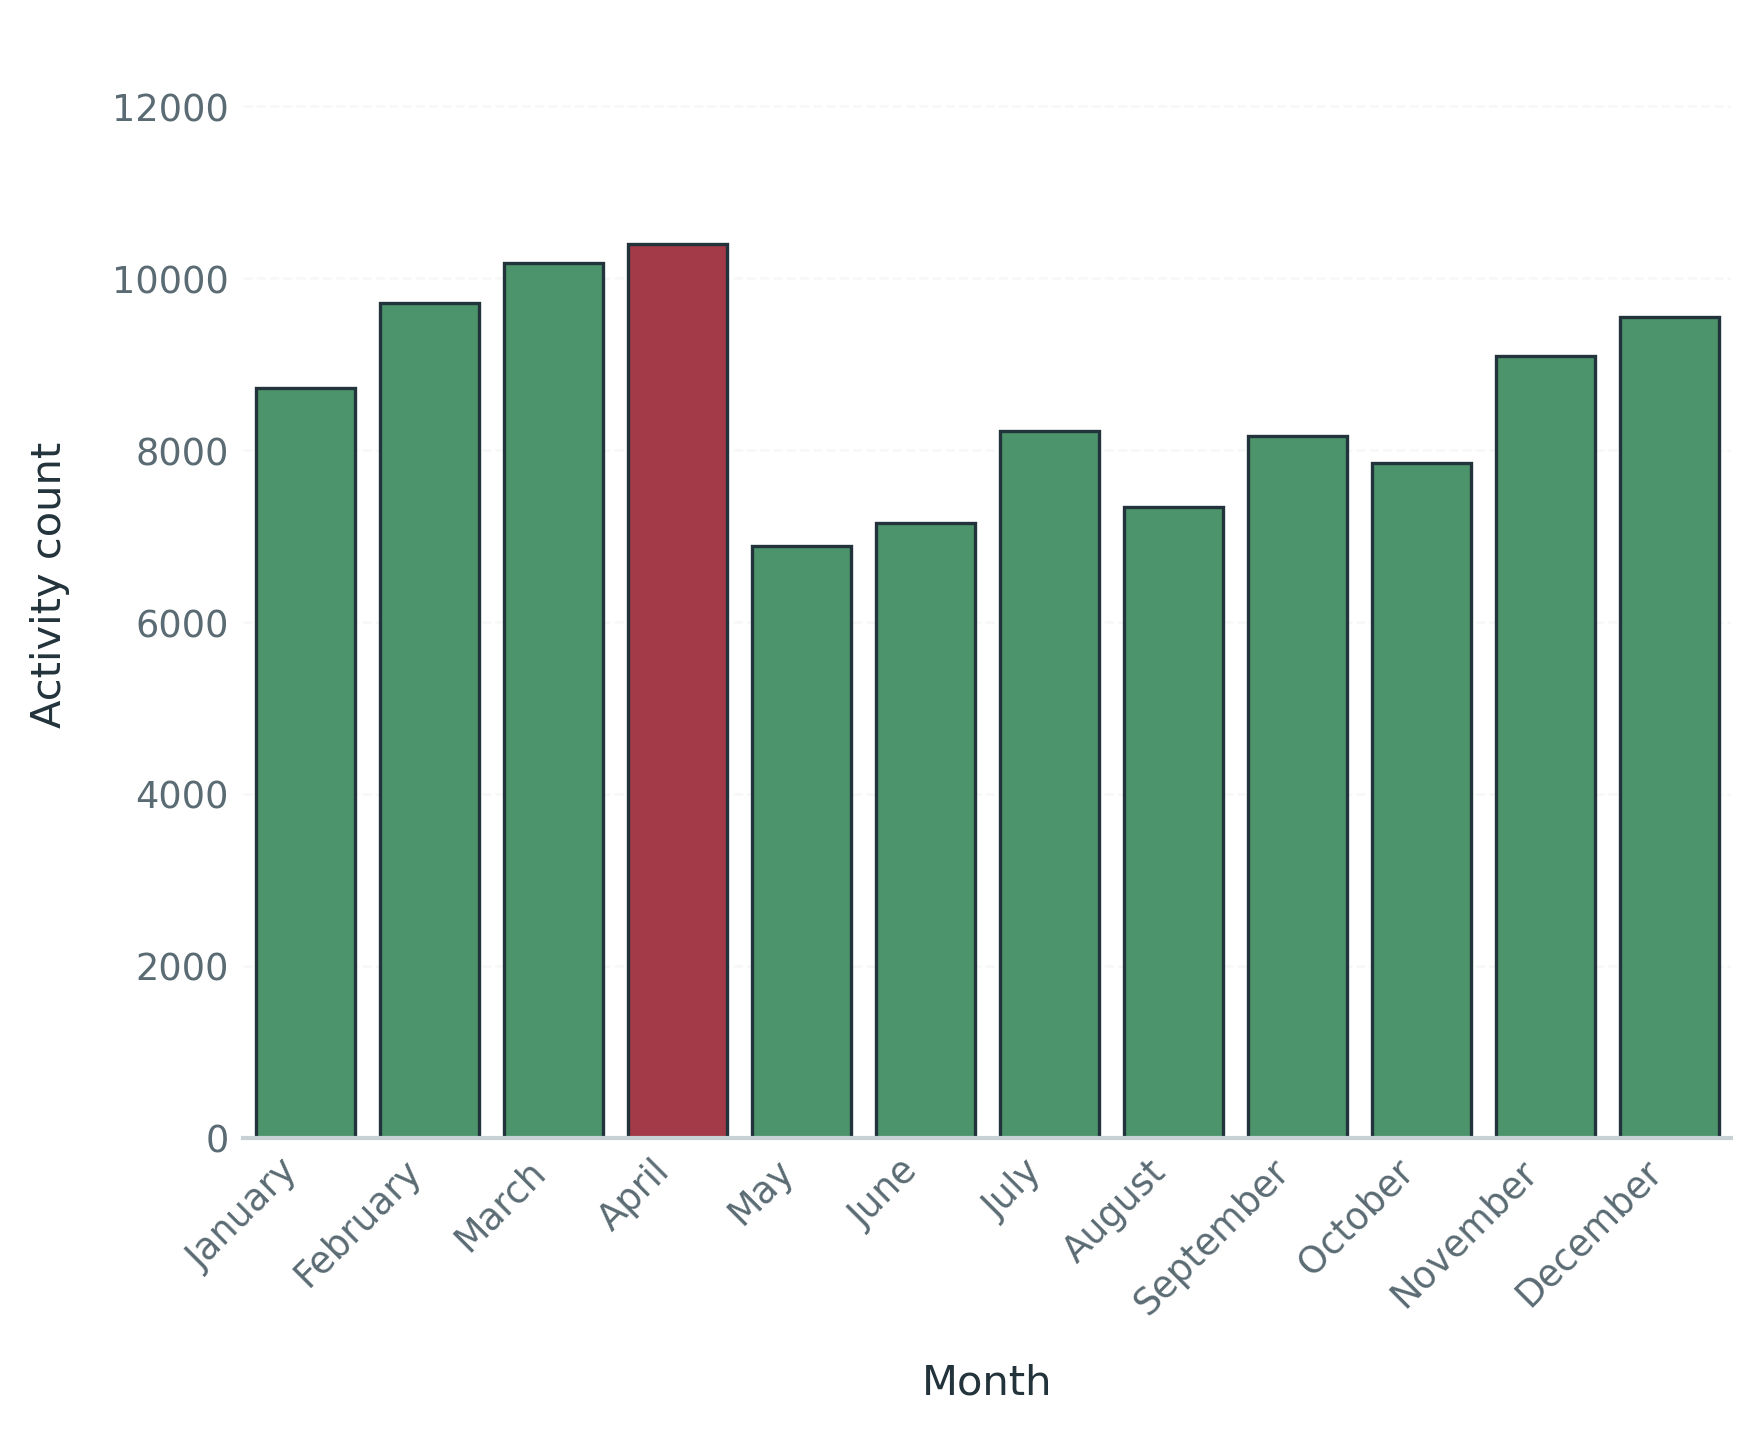

In [2]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path

from src.constants import paths_to_files_and_folders as const
import src.constants.thesis_plotting_style as style
from src.constants.columns import USER_ID_COL, VEHICLE_ID_COL, VEHICLE_END_YEAR_COL

from src.data_cleaning import DataCleaner
from src.plotting import PlottingData
from src.data_summary import DataSummary

## Inputs

The plotting and summary classes consume the **interim CSVs produced by
`05_data_cleaning_and_saving`**: raw (segmented, but no churn/cutoff filtering) for
distributional views, and filtered (truncated at churn) for the interval grid.
They are read with polars because the plotting/summary methods parse the string
date columns themselves.


In [3]:
INTERIM = Path(r"C:\Users\Tomas\Desktop\Thesis Stuff\Survival_Analysis_Thesis\Coding\Data\interim")

PERSONAL_RAW       = INTERIM / "personal_users_raw.csv"
PROFESSIONAL_RAW   = INTERIM / "professional_users_raw.csv"
PERSONAL_FILTERED  = INTERIM / "personal_users_filtered.csv"

personal_raw      = pl.read_csv(PERSONAL_RAW)
professional_raw  = pl.read_csv(PROFESSIONAL_RAW)
personal_filtered = pl.read_csv(PERSONAL_FILTERED)

plotter = PlottingData()
summary = DataSummary()


## 1. Raw-data sanity checks

These operate on the unmerged raw files and motivate decisions made inside
`DataCleaner` (dropping rows without a `vehicle_id`, dropping ambiguous
user/vehicle duplicates, and treating a missing `vehicle_end_year` as
still-in-production).


In [4]:
activity_df = pd.read_csv(const.PATH_TO_RAW_ACTIVITY_DATA_1000)
vehicle_df  = pd.read_csv(const.PATH_TO_RAW_VEHICLE_DATA_1000)

# Rows without a vehicle_id cannot carry static vehicle metadata downstream
print("NaN vehicle_id in activity:", activity_df["vehicle_id"].isna().sum())
print("NaN vehicle_id in vehicle :", vehicle_df["vehicle_id"].isna().sum())

# Share of activity vehicle_ids that have no metadata row at all
present = pd.Series(activity_df["vehicle_id"].unique()).isin(vehicle_df["vehicle_id"].unique()).sum()
missing_pct = (activity_df["vehicle_id"].nunique() - present) / activity_df["vehicle_id"].nunique()
print(f"vehicle_id metadata missing: {missing_pct * 100:.2f}%")

NaN vehicle_id in activity: 13117
NaN vehicle_id in vehicle : 0
vehicle_id metadata missing: 0.00%


In [5]:
# Users whose same vehicle_id appears under conflicting metadata rows (dropped on merge)
dupe = (vehicle_df.groupby([USER_ID_COL, VEHICLE_ID_COL])[VEHICLE_ID_COL]
        .count().gt(1).groupby(level=0).any())
print("Users with duplicate vehicle metadata:", int(dupe.sum()))

# Missing end-year => model still in production. ~7.5% confirms most cars are discontinued
print(f"vehicle_end_year missing: {vehicle_df[VEHICLE_END_YEAR_COL].isna().mean() * 100:.2f}%")

# 95th percentile of unique vehicles per user — informs the quantile split criterion
print("95th pct unique vehicles/user:",
      vehicle_df.groupby(USER_ID_COL)[VEHICLE_ID_COL].nunique().quantile(0.95))

Users with duplicate vehicle metadata: 1
vehicle_end_year missing: 7.52%
95th pct unique vehicles/user: 35.0


## 2. User segmentation (personal vs professional)

The split itself lives in `DataCleaner.filter_users_by_type` (an OR of three
criteria: effective inverse-HHI, top-4 vehicle share, and a unique-vehicle-count
quantile, each covering the others' blind spots). Here we just load the already
segmented raw files and report their sizes.


In [6]:
print("Personal users    :", personal_raw[USER_ID_COL].n_unique())
print("Professional users:", professional_raw[USER_ID_COL].n_unique())

Personal users    : 2435
Professional users: 215


## 3. Activity-type distribution

Composition of what users actually do. Run per segment to contrast personal vs
professional behaviour. Counts are at the raw-activity level (no burst collapse),
because the mix of actions is the quantity of interest.


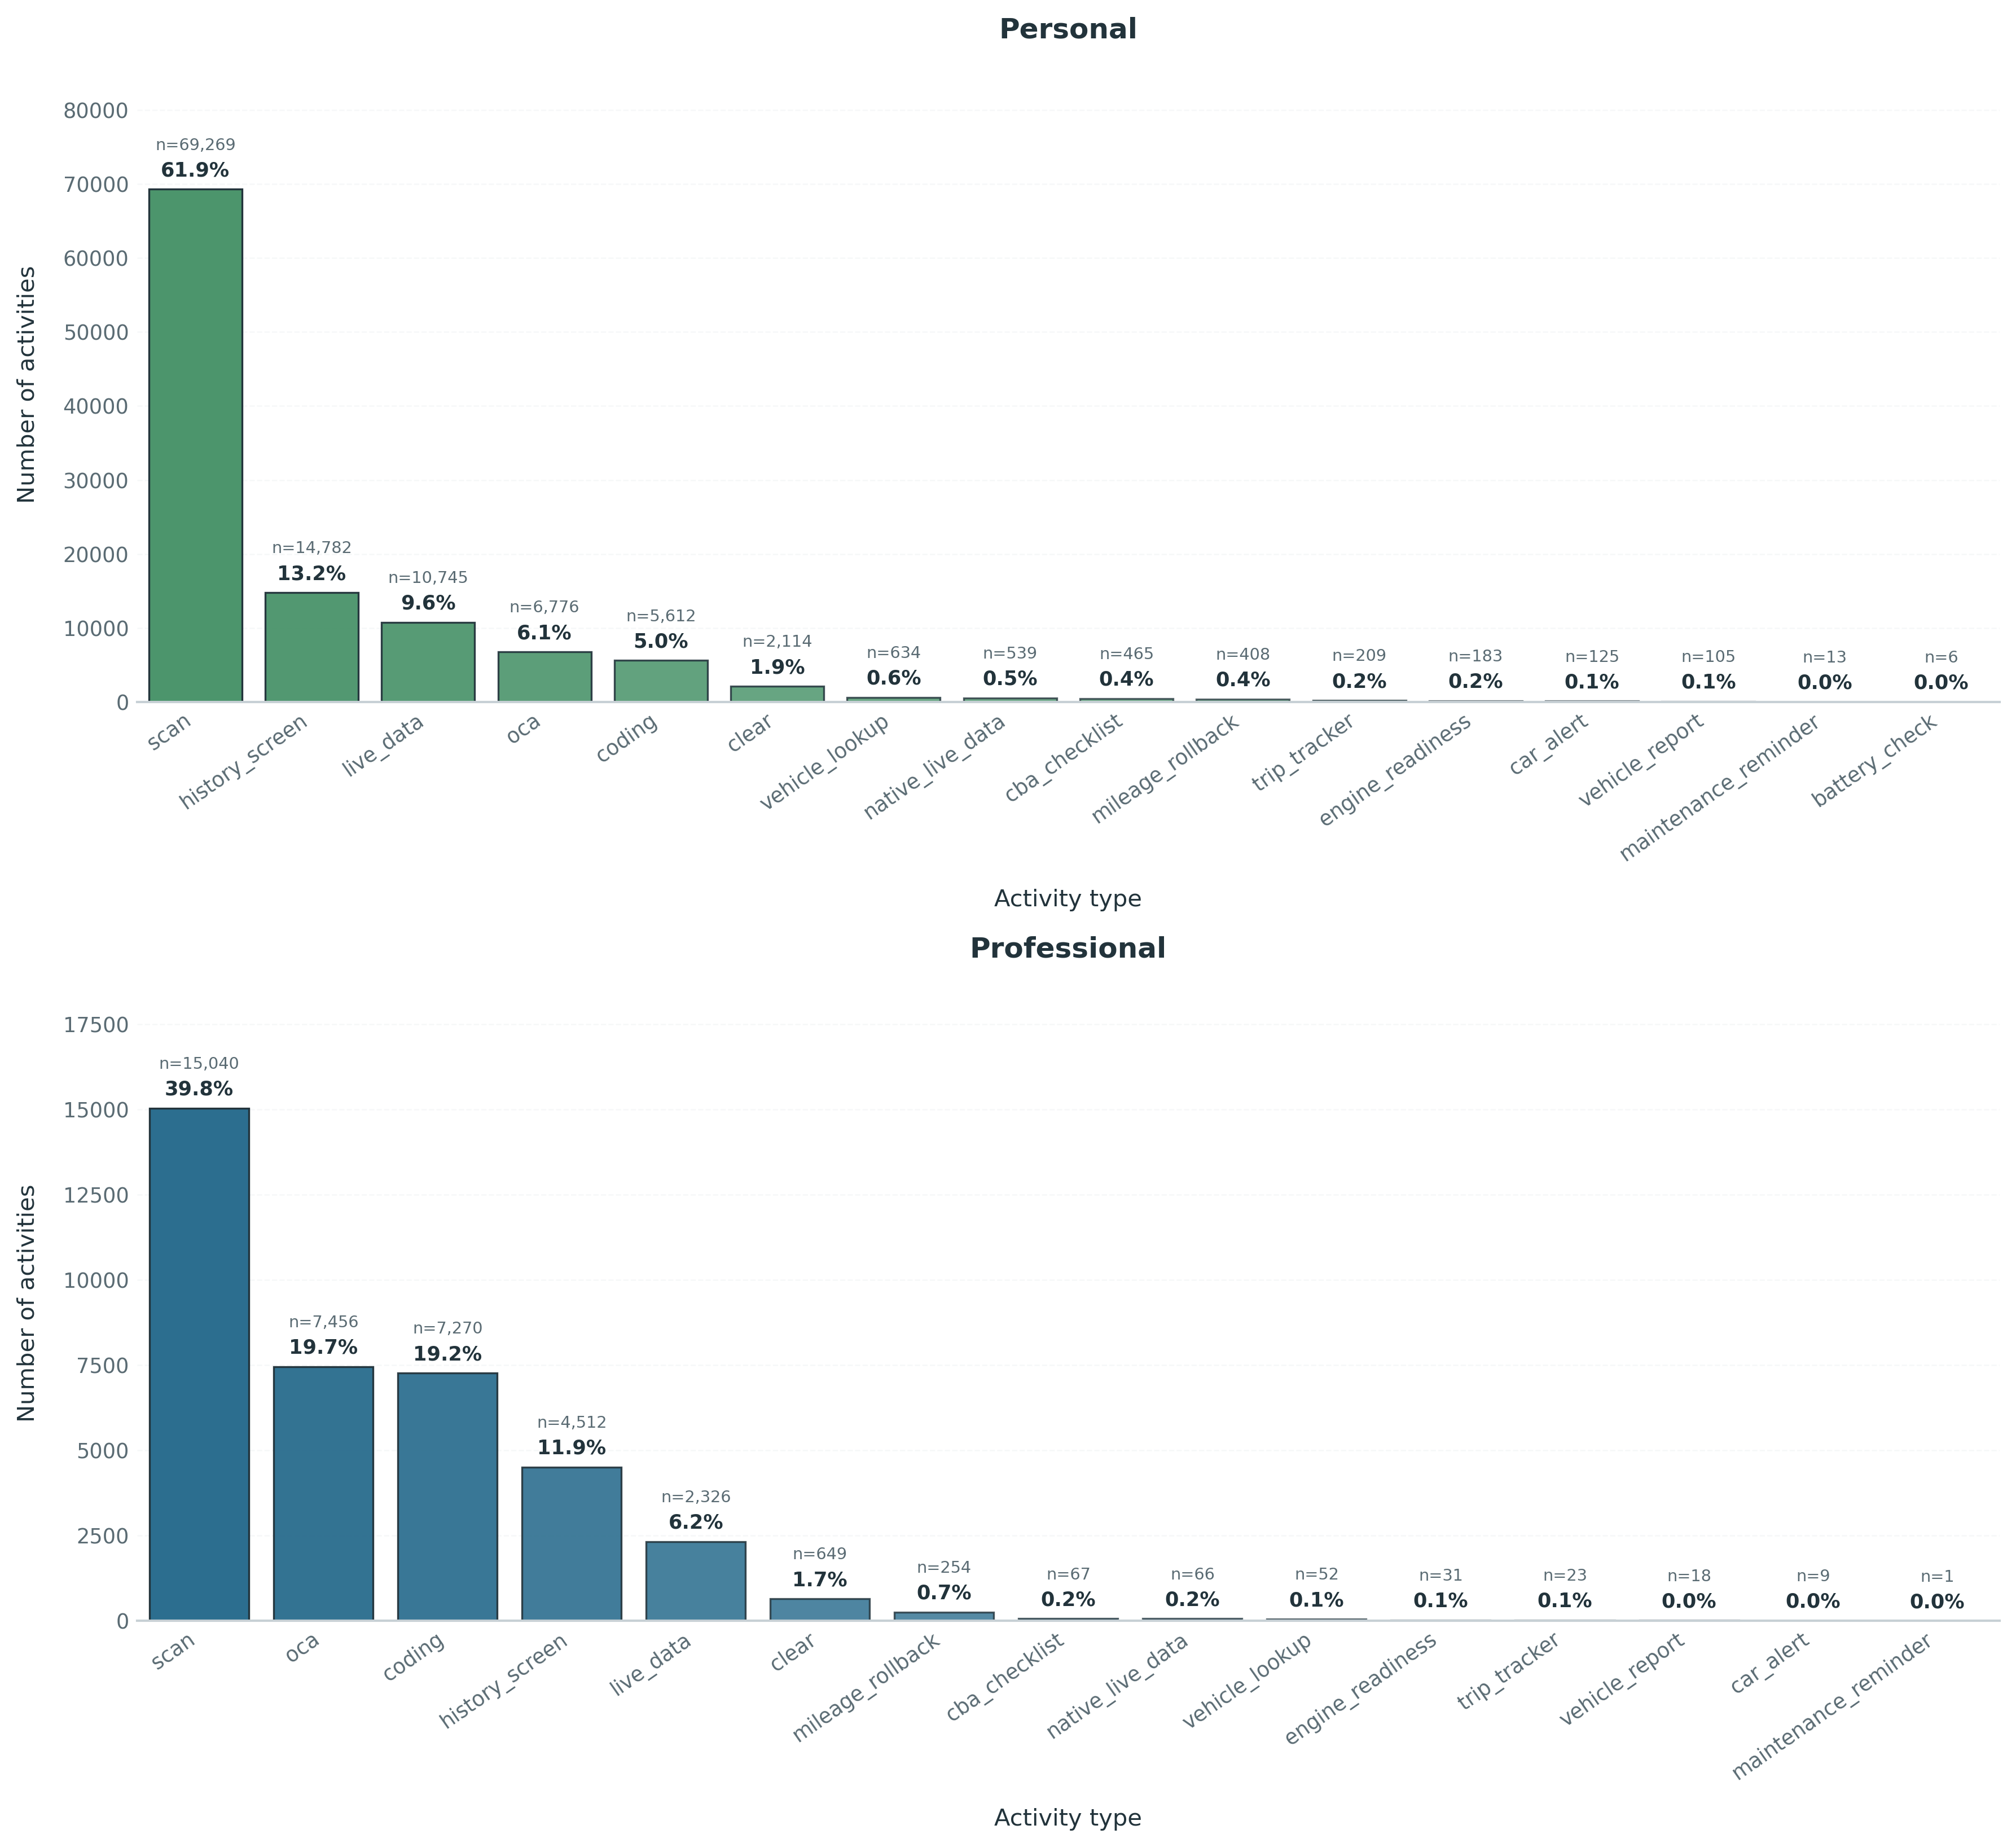

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 11))

plotter.return_activity_distribution_plot(personal_raw,     ax=axes[0], personal=True)
plotter.return_activity_distribution_plot(professional_raw, ax=axes[1], personal=False)

axes[0].set_title("Personal",     fontweight="bold", pad=12)
axes[1].set_title("Professional", fontweight="bold", pad=12)
fig.tight_layout()
plt.show()

## 4. User-split validation

Each user plotted by unique-vehicle count vs top-4 vehicle share, sized by
effective HHI. This is a visual check that the split landed where intended:
personal users should cluster at low vehicle counts and high concentration,
professionals should spread toward many vehicles and lower concentration. The
diagnostics are computed on burst-filtered data, matching the classifier.


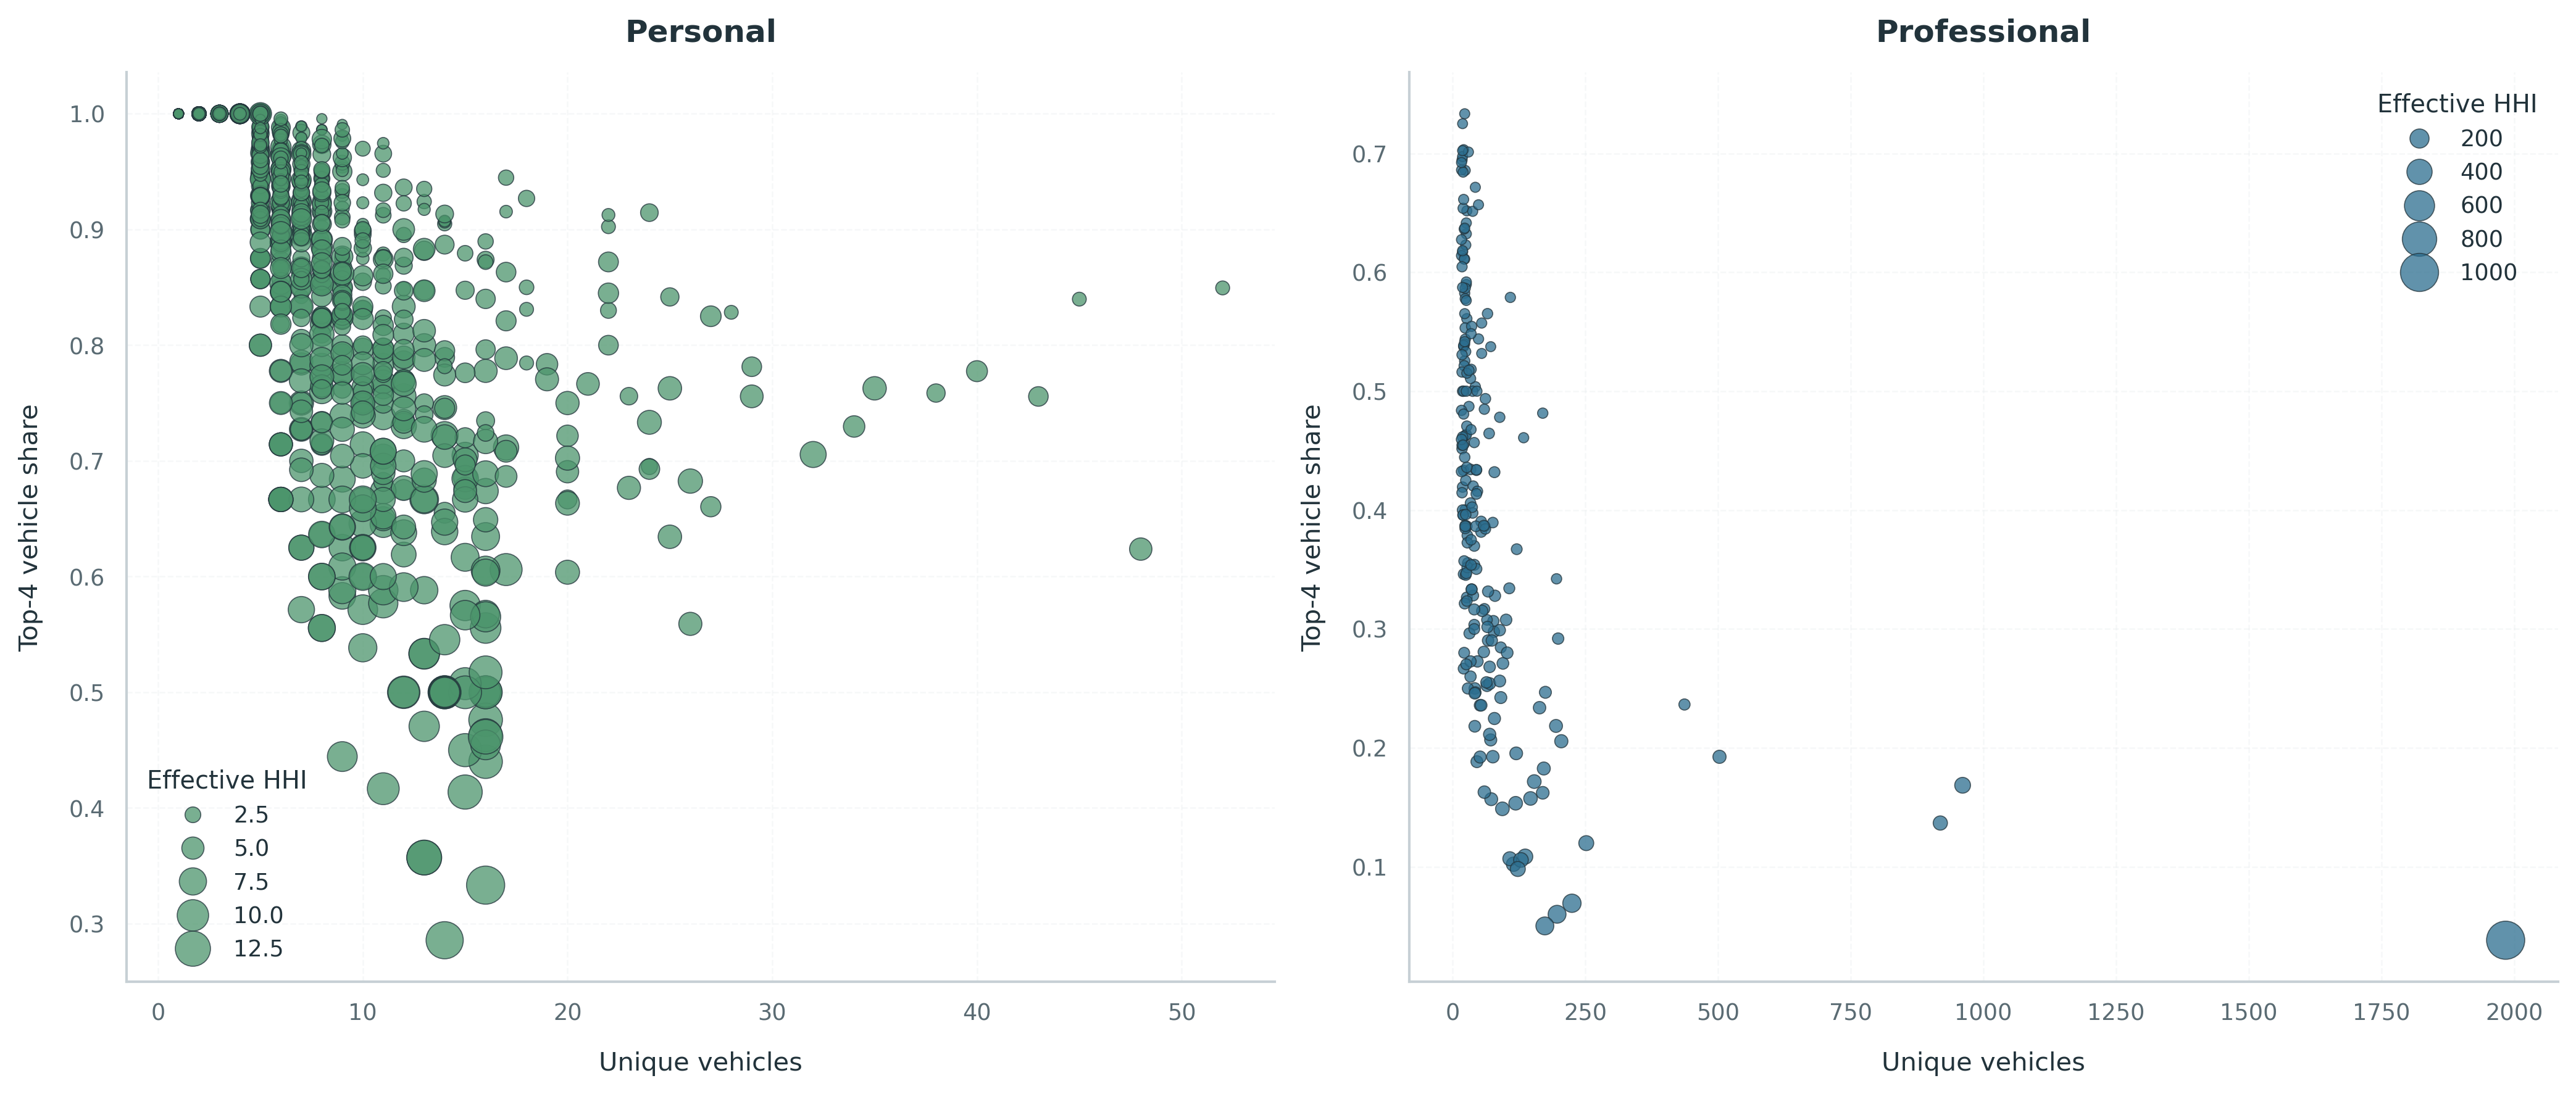

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plotter.return_user_split_plot(personal_raw,     ax=axes[0], personal=True)
plotter.return_user_split_plot(professional_raw, ax=axes[1], personal=False)

axes[0].set_title("Personal",     fontweight="bold", pad=12)
axes[1].set_title("Professional", fontweight="bold", pad=12)
fig.tight_layout()
plt.show()

## 5. Inter-activity gap distribution

Days between consecutive active days — the core evidence for the churn threshold
and the interval/lookback sizes. Read on **raw** data so the long right tail is
intact; quantile lines mark the median and 95th percentile, and the x-axis is
trimmed at the 99th percentile so the tail does not flatten the visible mass.


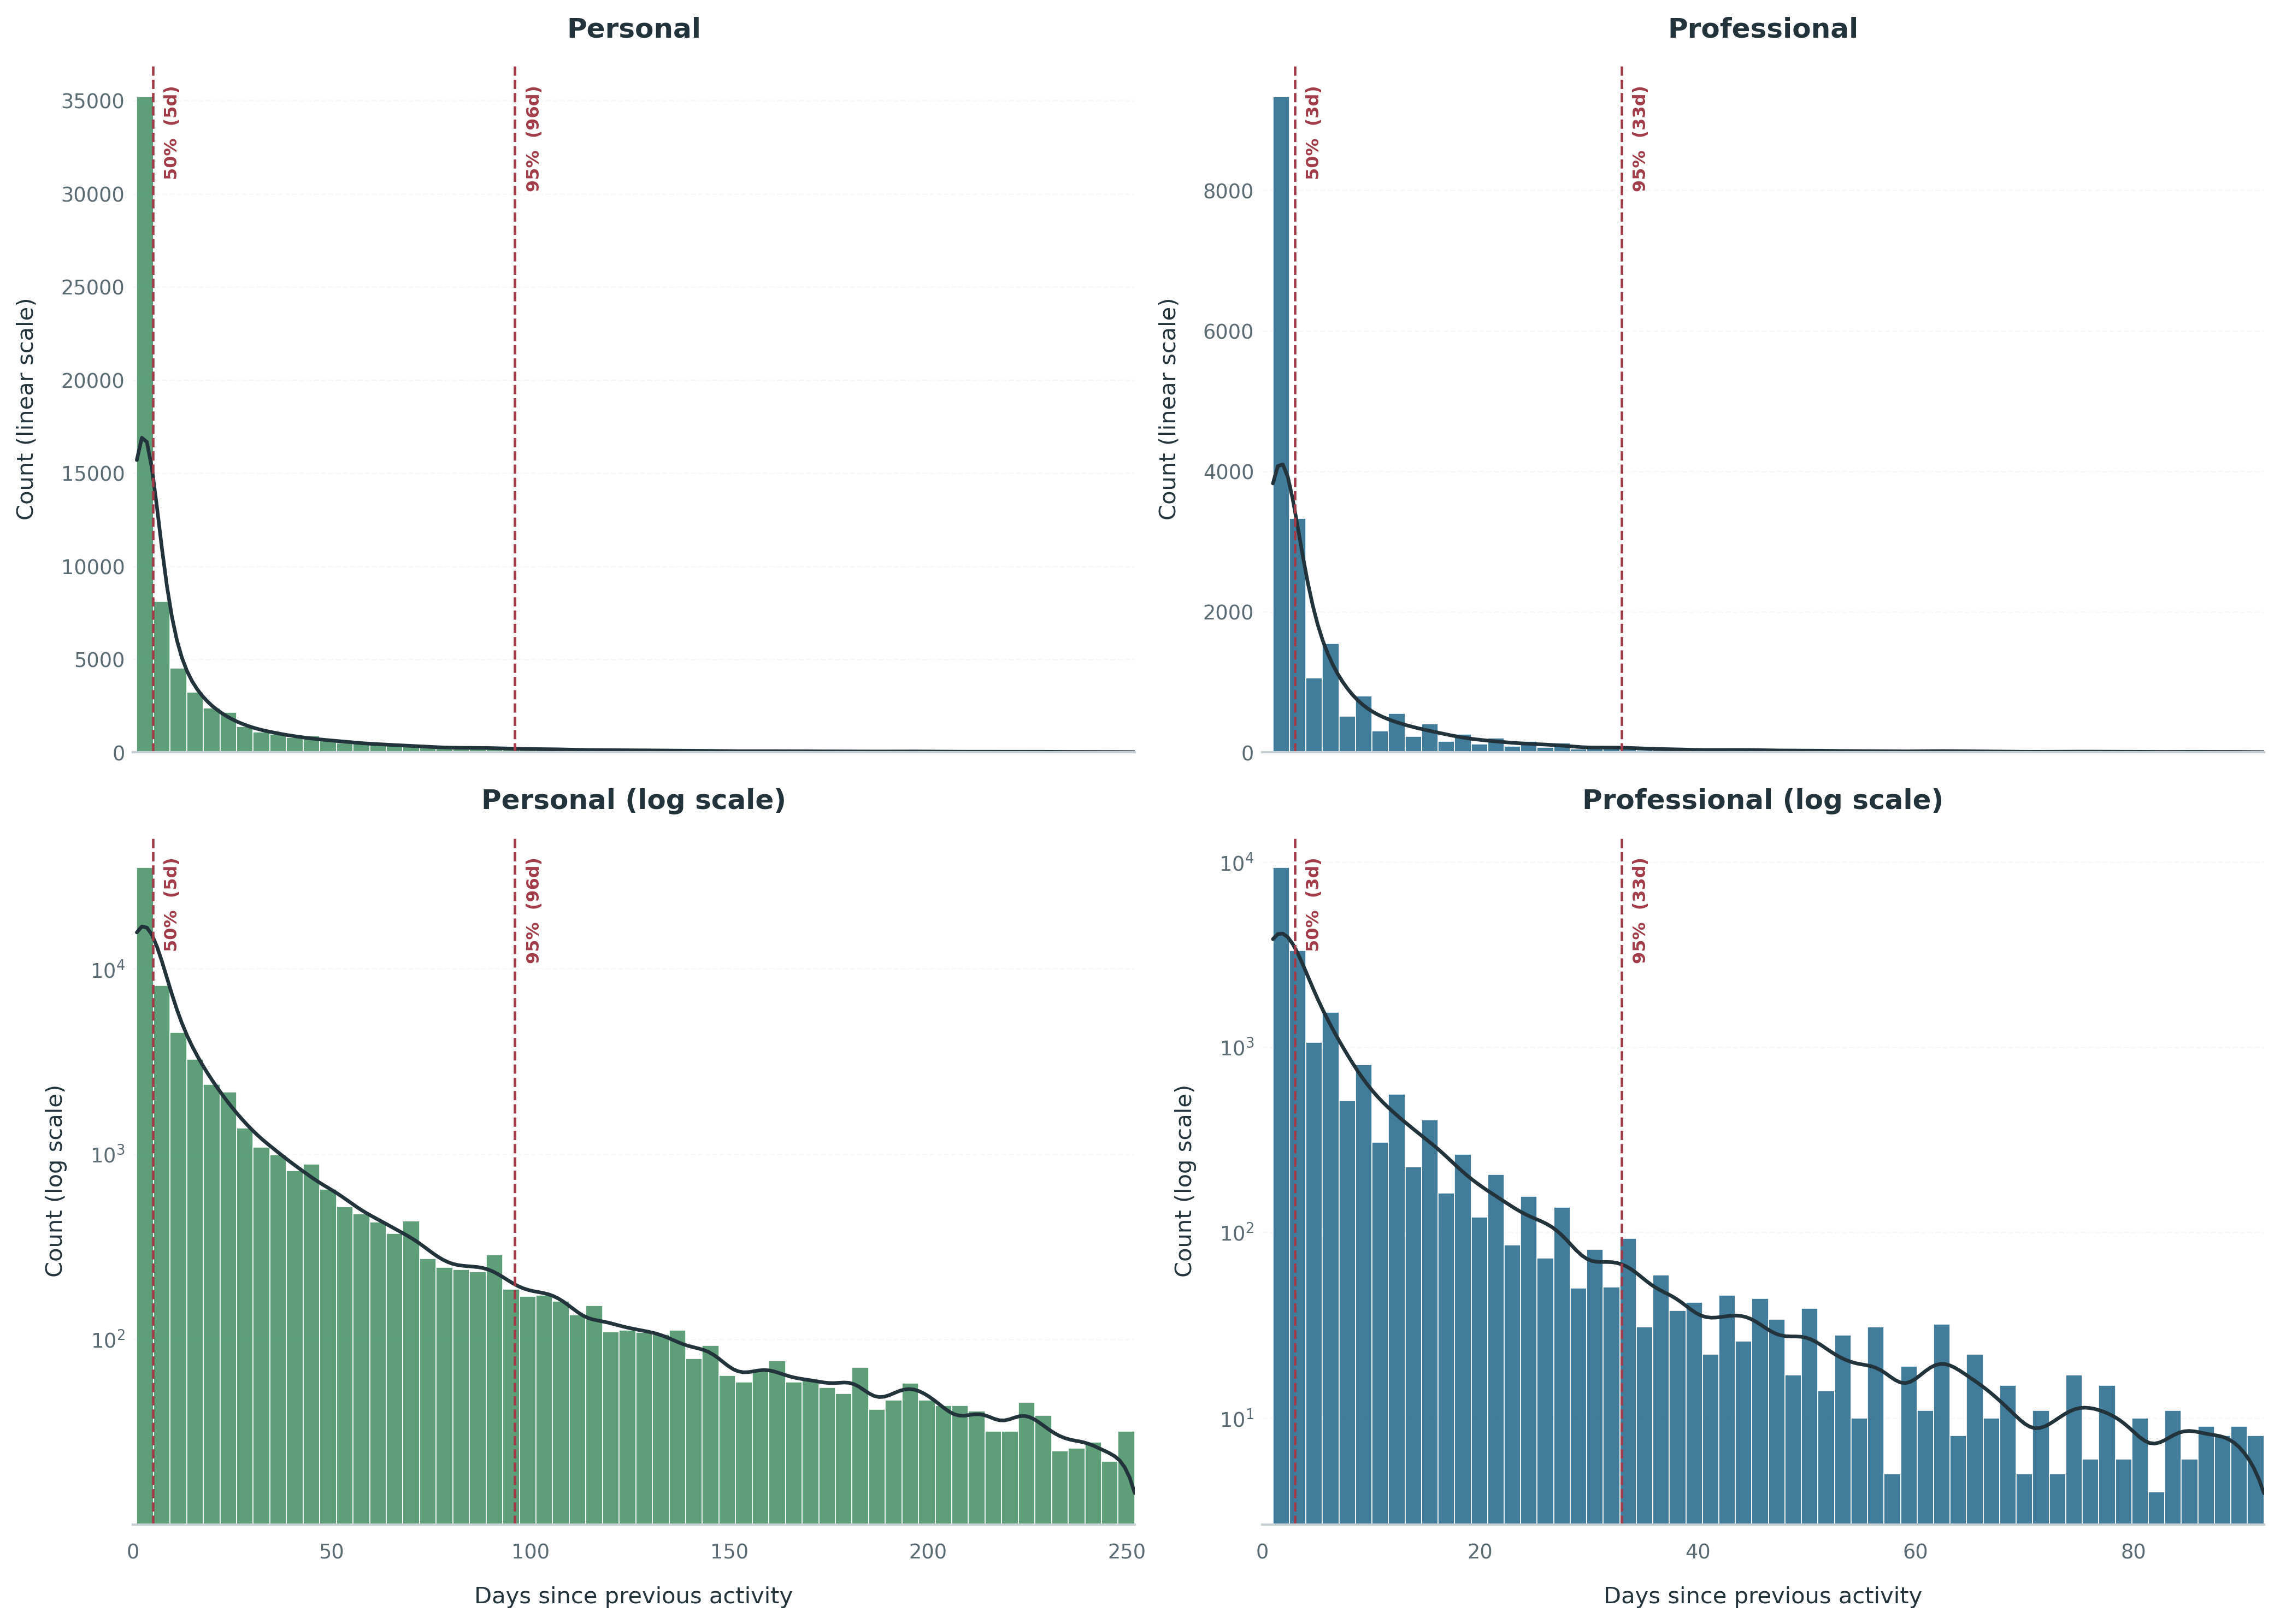

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex="col")

plotter.return_activity_gap_distribution(
    personal_raw, ax=axes[0, 0], personal=True,
    quantiles=[0.5, 0.95], quantile_boundary=0.99)
plotter.return_activity_gap_distribution(
    professional_raw, ax=axes[0, 1], personal=False,
    quantiles=[0.5, 0.95], quantile_boundary=0.99)
plotter.return_activity_gap_distribution(
    personal_raw, ax=axes[1, 0], personal=True,
    quantiles=[0.5, 0.95], quantile_boundary=0.99,
    set_y_scale_to_log=True)
plotter.return_activity_gap_distribution(
    professional_raw, ax=axes[1, 1], personal=False,
    quantiles=[0.5, 0.95], quantile_boundary=0.99,
    set_y_scale_to_log=True)

axes[0, 0].set_title("Personal",             fontweight="bold", pad=12)
axes[0, 1].set_title("Professional",         fontweight="bold", pad=12)
axes[1, 0].set_title("Personal (log scale)", fontweight="bold", pad=12)
axes[1, 1].set_title("Professional (log scale)", fontweight="bold", pad=12)

fig.tight_layout()
plt.show()

In [10]:
print("Personal gap (days):")
print(summary.return_activity_gap_summary(personal_raw))
print()
print("Professional gap (days):")
print(summary.return_activity_gap_summary(professional_raw))

Personal gap (days):
            gap_days
count  100867.000000
mean       14.714646
std        45.237273
min         0.000012
25%         0.157292
50%         1.739028
75%         9.461481
90%        35.756160
95%        70.020920
99%       209.928874
max      2142.893021

Professional gap (days):
           gap_days
count  35325.000000
mean       5.154946
std       19.298158
min        0.000012
25%        0.051412
50%        0.873495
75%        3.850590
90%       11.844947
95%       21.660104
99%       66.923762
max     1012.269630


## 6. Interval-width selection

Trades intervals-per-user against the empty-interval rate for each candidate
width. Run on the **filtered** dataset, since the grid spans each user's at-risk
window (needs `churn_adjusted_date`). 14d gives finer resolution but a higher
empty rate; 28d is coarser but cleaner. Empty intervals are not waste — under the
counting-process formulation they are explicit "no activity" observations.


In [11]:
summary.return_interval_summary(personal_filtered, interval_sizes=[14, 28])

c:\Users\Tomas\Desktop\Thesis Stuff\Survival_Analysis_Thesis\Coding\src\data_summary.py:78: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_with_intervals = df.join_asof(
c:\Users\Tomas\Desktop\Thesis Stuff\Survival_Analysis_Thesis\Coding\src\data_summary.py:78: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_with_intervals = df.join_asof(


,interval_days,mean_intervals,median_intervals,p25_intervals,p75_intervals,empty_interval_rate
0,14,27.853002,21.0,14.0,35.0,0.6060
1,28,14.187164,11.0,7.0,18.0,0.4354


## 7. Seasonality

Activity by calendar month, peak highlighted. Read on **raw** data (truncating at
churn would drop later months and bias the seasonal shape); bursts are collapsed
so a single session counts once.


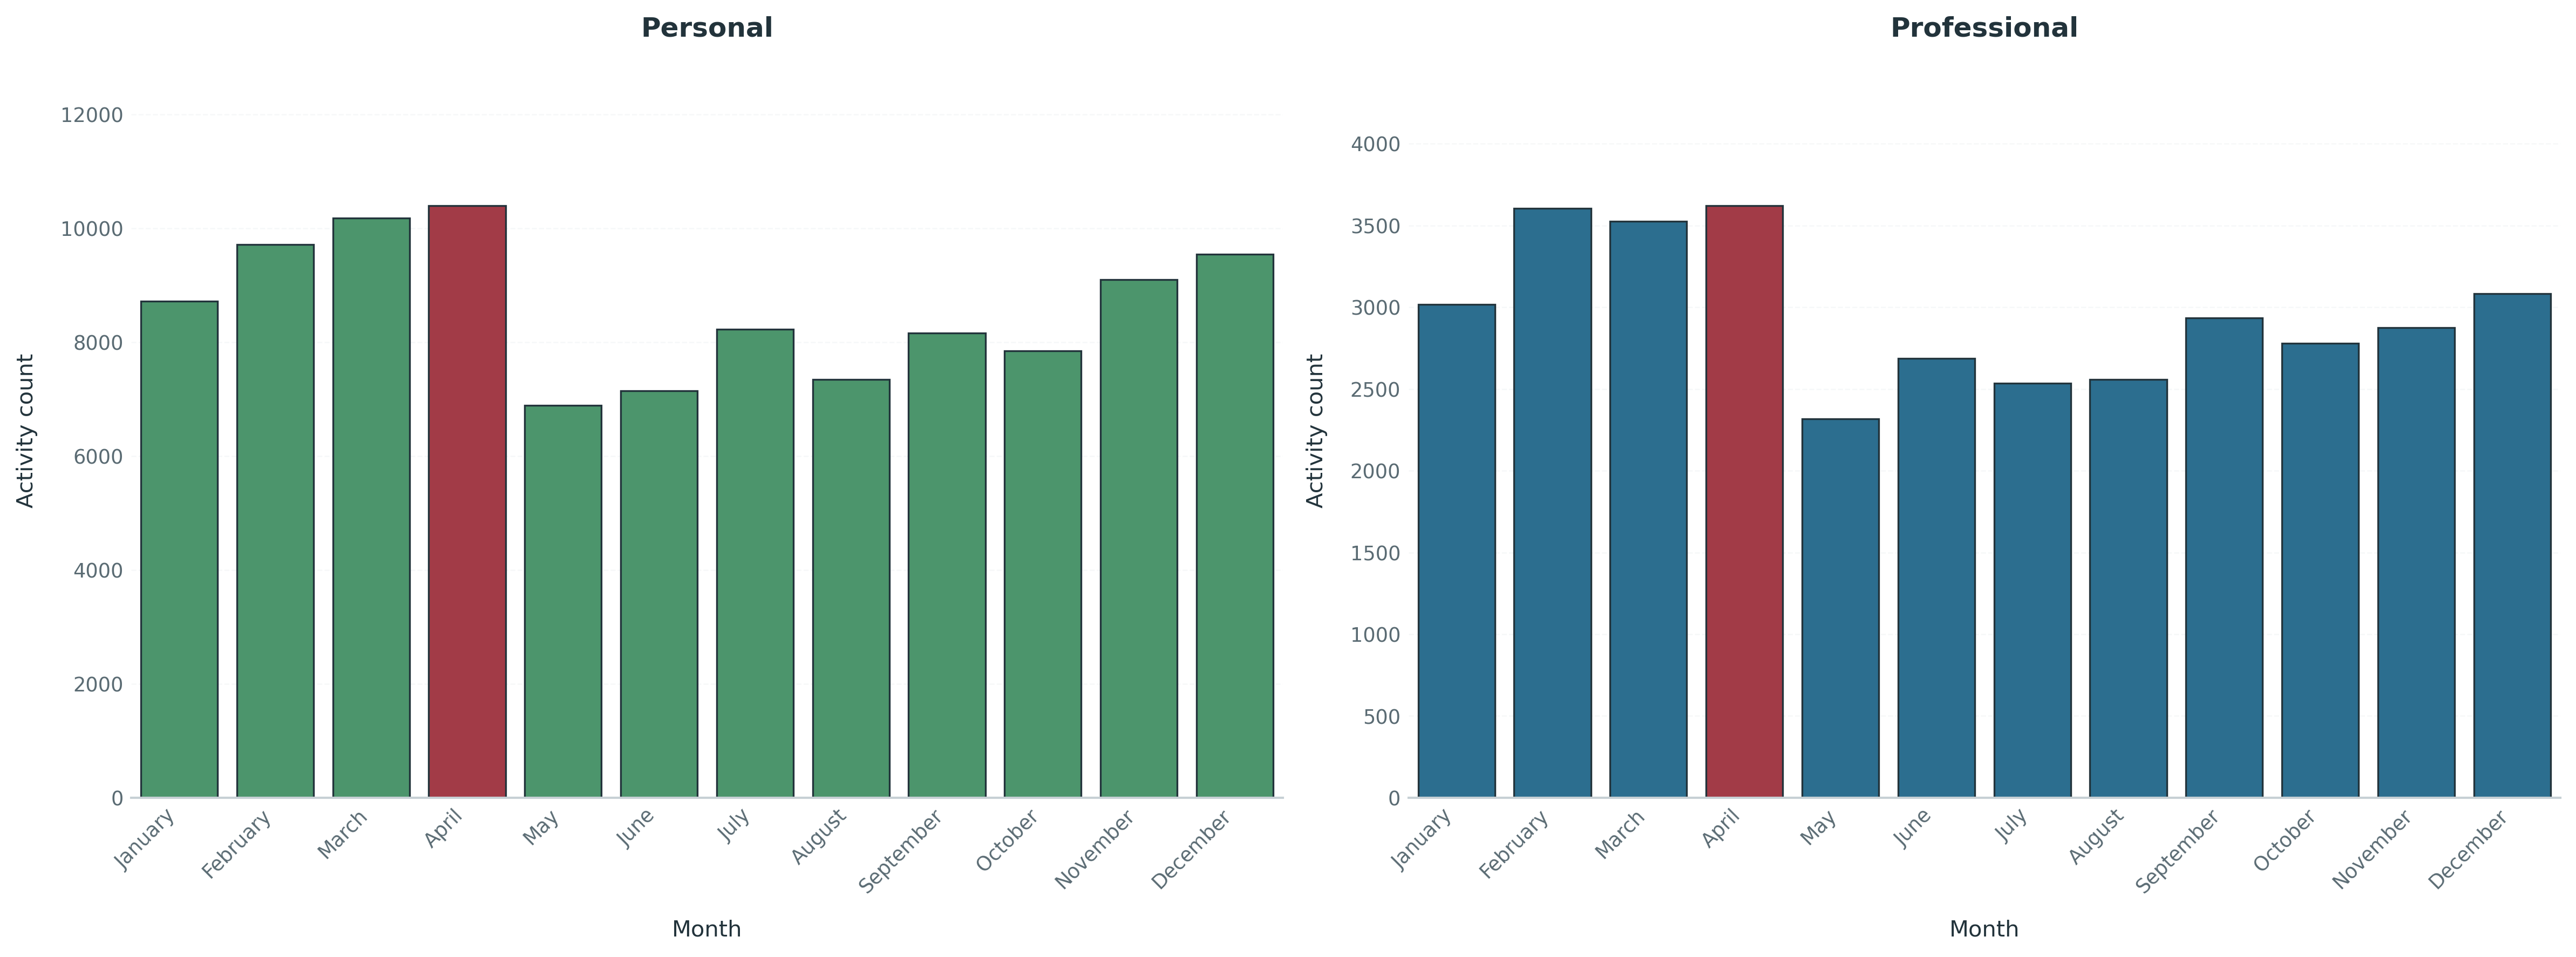

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plotter.return_seasonality_plot(personal_raw,     ax=axes[0], personal=True)
plotter.return_seasonality_plot(professional_raw, ax=axes[1], personal=False)

axes[0].set_title("Personal",     fontweight="bold", pad=12)
axes[1].set_title("Professional", fontweight="bold", pad=12)
fig.tight_layout()
plt.show()

## 8. Vehicle-make distribution

Make composition at the vehicle level (deduplicated by `vehicle_id`). Justifies
the make grouping and the per-make proportion features. Makes are raw here; the
`brand_group_map` collapsing (e.g. Mini into the BMW group) happens later in
feature engineering.


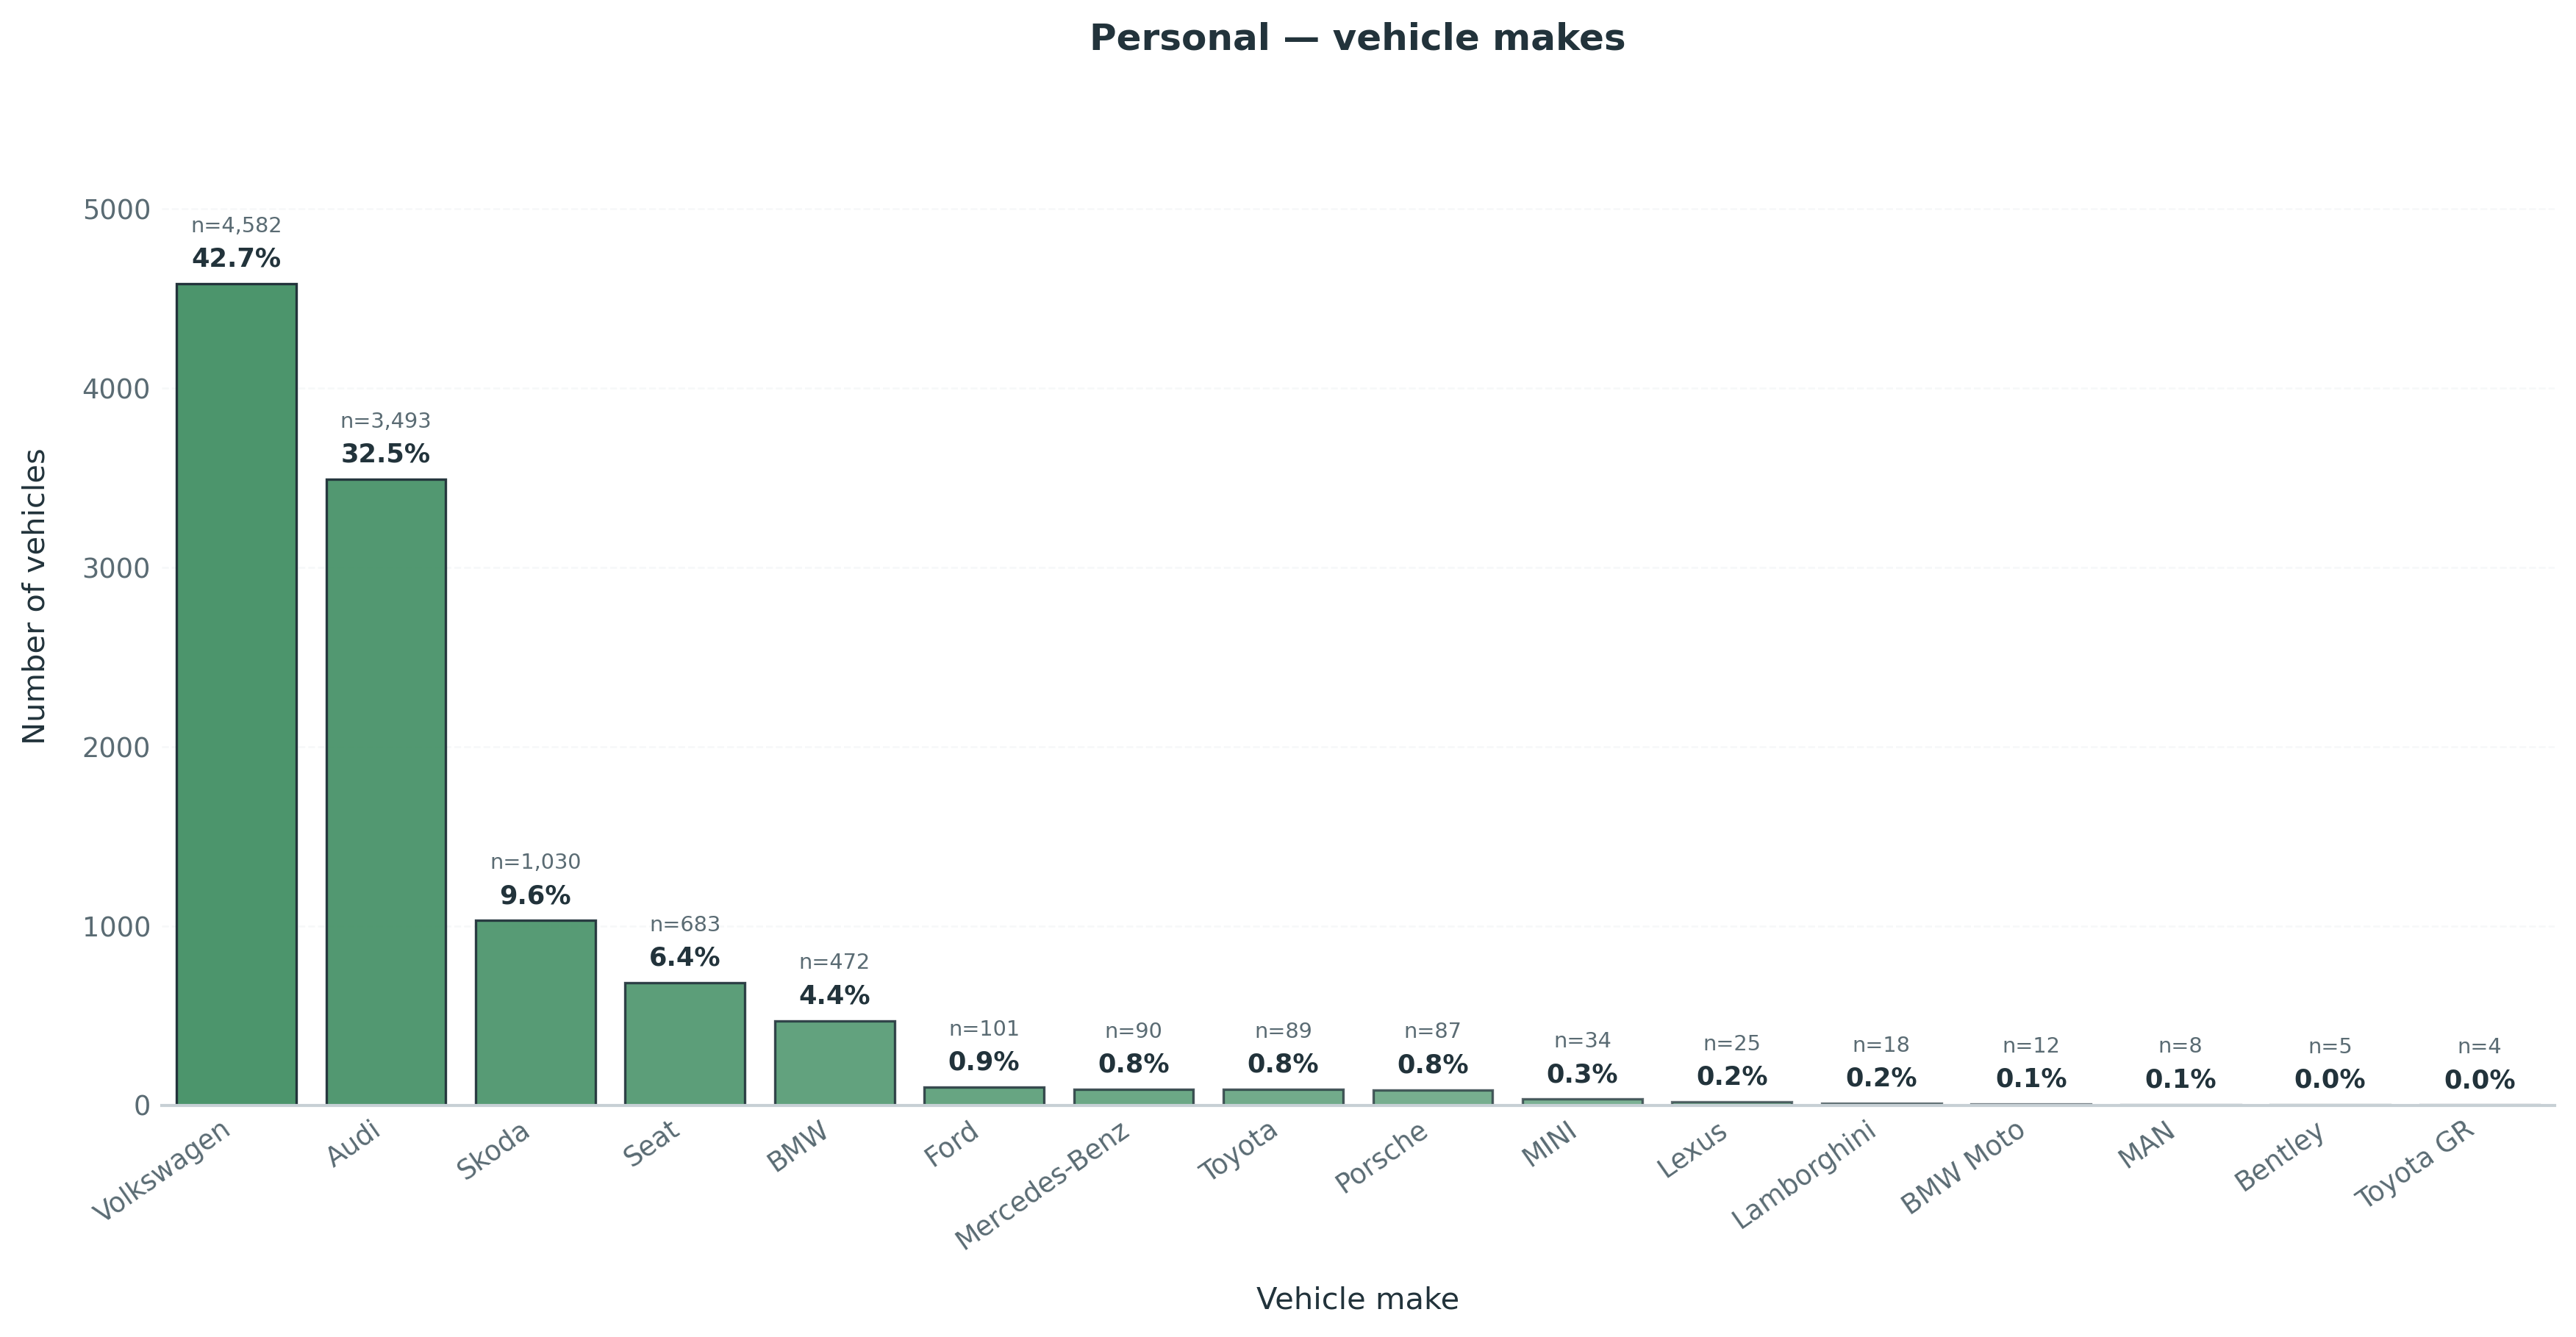

In [13]:
fig, ax = plt.subplots(figsize=(14, 6))
plotter.return_vehicle_make_distribution_plot(personal_raw, ax=ax, personal=True)
ax.set_title("Personal — vehicle makes", fontweight="bold", pad=12)
plt.show()
